## Сегментация изображений клеток

Вам предстоит обучить модель сегментировать изображения с дрожжевыми клетками и микроструктурами (см. [06_segmentation.ipynb](../workshops/06_segmentation.ipynb)), по пути поэкспериментировав с разными архитектурами и функцими ошибки.

### Задание 1 (2 балл). Метрики сегментации
Перед экспериментами нужно определиться с метриками. Выберите 3-5 метрик, по которым вы будете оценивать качество модели. В этом задании объясните свой выбор и найдите нужные метрики в `torchvision` (а если их нет - реализуйте самостоятельно, здесь вам может помочь [05_lightning_etc.ipynb](../workshops/05_lightning_etc.ipynb))

- Accuracy: Чтобы понять, насколько хорошо модель предсказывает классы пикселей в целом
- IoU: Чтобы понять про конкретный класс, насколько совпадают его реальные пиксели и пиксели предсказания
- Precision и Recall: Чтобы отследить степень ложноположительных или ложноотрицательных результатов

In [76]:
# ! wget https://tudatalib.ulb.tu-darmstadt.de/bitstream/handle/tudatalib/3799/yeast_cell_in_microstructures_dataset.zip
# ! unzip yeast_cell_in_microstructures_dataset.zip -d yeast_cell_in_microstructures_dataset
# ! pip install torchmetrics lightning

import torchmetrics

accuracy_metric = torchmetrics.Accuracy(task="multiclass", num_classes=3)

iou_metric = torchmetrics.JaccardIndex(task="multiclass", num_classes=3)

precision_metric = torchmetrics.Precision(task="multiclass", num_classes=3, average='none')
recall_metric = torchmetrics.Recall(task="multiclass", num_classes=3, average='none')

### Задание 2 (4 балла). Обучение модели
Возьмите модель и датасеты из практики по сегментации и запустите обучение.

Указания:
- Каждую эпоху сохраняйте значения ошибки и выбранные в задании 1 метрики как для обучающего датасета (`train`), так и для валидационного (`val`).
- Каждую эпоху сохраняйте примеры работы модели на 8 случайных изображениях из валидационного датасета (одной картинкой, как в практике).
- После окончания обучения выведите графики значений ваших метрик и примеры предсказаний (достаточно 4-5 изображений: для первой эпохи, 2-3 в середине обучения и ндля последней эпохи).
- Можете использовать `lightning` (вместо `lightning.pytorch.loggers.TensorBoardLogger` можно использовать `lightning.pytorch.loggers.CSVLogger`, а сохранение изображений можете реализовать как `lightning.pytorch.Callback`), а можете всё написать вручную.

In [77]:
from pathlib import Path

import lightning as L
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch import Tensor
from torch.utils.data import Dataset
from torchvision import transforms

import lightning as L
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from pathlib import Path
from torchvision import transforms
import torchvision
import matplotlib.pyplot as plt
from torchmetrics import (
    Accuracy,
    JaccardIndex,
    Precision,
    Recall,
    MeanMetric
)
from typing import Any, Callable, Type

class YeastDataset(Dataset):
    def __init__(self, subset_dir: Path) -> None:
        super().__init__()
        self.subset_dir = subset_dir
        self.items = list((self.subset_dir / "inputs").glob("*.pt"))

    def __getitem__(self, index: int) -> tuple[Tensor, dict[str, Tensor]]:
        # нужно вернуть пару
        # тензор изображения C x W x H
        # словарь с ключами boxes, masks, labels
        image_path = self.items[index]
        image = torch.load(image_path, weights_only=True).unsqueeze(
            0
        )  # (W, H) -> (1, W, H)
        classes = (
            torch.load(
                self.subset_dir / "classes" / image_path.parts[-1], weights_only=True
            )
            + 1
        )  # 0 класс - фон
        masks = torch.load(
            self.subset_dir / "instances" / image_path.parts[-1], weights_only=True
        )
        boxes = torch.load(
            self.subset_dir / "bounding_boxes" / image_path.parts[-1], weights_only=True
        )
        return image, dict(
            boxes=boxes,
            labels=classes,
            masks=masks,
        )

    def __len__(self) -> int:
        return len(self.items)

class YeastSemanticSegmDataset(YeastDataset):
    def __getitem__(self, index: int) -> tuple[Tensor, Tensor]:
        image, annotation = super().__getitem__(index)
        # нужно сформировать маску: тензор размера W x H, где для каждого пиксела указан класс
        mask = (
            (annotation["masks"] * annotation["labels"].view(-1, 1, 1)).sum(dim=0)
        ).long()

        return image, mask

from typing import Any, Callable, Type

from lightning.pytorch.utilities.types import EVAL_DATALOADERS, TRAIN_DATALOADERS
from torch.utils.data import DataLoader

_collate_fn_t = Callable[[list[tuple[Tensor, Any]]], Any]


class Datamodule(L.LightningDataModule):
    def __init__(
        self,
        datadir: Path,
        dataset_class: Type[Dataset],
        batch_size: int,
        train_subdir: str = "train",
        val_subdir: str = "val",
        test_subdir: str = "test",
    ) -> None:
        super().__init__()
        self.batch_size = batch_size
        self.dataset_class = dataset_class
        self.train_dir = datadir / train_subdir
        self.val_dir = datadir / val_subdir
        self.test_dir = datadir / test_subdir

    @property
    def collate_fn(self) -> _collate_fn_t | None:
        if self.dataset_class == YeastSemanticSegmDataset:
            return None
        else:
            return lambda batch: tuple(zip(*batch))

    def setup(self, stage: str) -> None:
        if stage in ("fit", "validate"):
            self.val_dataset = self.dataset_class(self.val_dir)
        if stage == "fit":
            self.train_dataset = self.dataset_class(self.train_dir)
        elif stage == "test":
            self.test_dataset = self.dataset_class(self.test_dir)

    def train_dataloader(self) -> TRAIN_DATALOADERS:
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            collate_fn=self.collate_fn,
        )

    def val_dataloader(self) -> EVAL_DATALOADERS:
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=self.collate_fn,
        )

    def test_dataloader(self) -> EVAL_DATALOADERS:
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=self.collate_fn,
        )

class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(
        self, in_channels: int, out_channels: int, mid_channels: int | None = None
    ) -> None:
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels: int, out_channels: int) -> None:
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2), DoubleConv(in_channels, out_channels)
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then double conv"""

    def __init__(
        self, in_channels: int, out_channels: int, bilinear: bool = True
    ) -> None:
        super().__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(
                in_channels, in_channels // 2, kernel_size=2, stride=2
            )
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x_prev: Tensor, x_skip: Tensor) -> Tensor:
        x_prev = self.up(x_prev)
        # input is BCHW
        d_height = x_skip.size()[2] - x_prev.size()[2]
        d_width = x_skip.size()[3] - x_prev.size()[3]

        x_prev = F.pad(
            x_prev,
            [
                d_width // 2,
                d_width - d_width // 2,
                d_height // 2,
                d_height - d_height // 2,
            ],
        )
        x = torch.cat([x_skip, x_prev], dim=1)
        return self.conv(x)

class UNet(nn.Module):
    def __init__(
        self,
        n_channels: int,
        n_classes: int,
        channel_sizes: list[int],
        bilinear: bool = False,
    ):
        super().__init__()
        self.in_conv = DoubleConv(in_channels=n_channels, out_channels=channel_sizes[0])
        self.downscaler = self.create_downscaler(channel_sizes, bilinear)
        self.upscaler = self.create_upscaler(channel_sizes[::-1], bilinear)
        self.head = nn.Conv2d(channel_sizes[0], n_classes, kernel_size=1)

    @classmethod
    def create_downscaler(
        cls, channel_sizes: list[int], bilinear: bool = False
    ) -> nn.ModuleList:
        """
        Создаём список модулей на основе размеров каналов.
        если используется билинейная интерполяция вместо обратной свёртки,
        то размер последнего (самого большого) канала делаем вдвое меньше

        Args:
            channel_sizes (list[int]): список размеров каналов, напр. [16, 32, 64]
            bilinear (bool, optional): если True, в модели используется билинейная интерполяция
                для выравнивания размеров активаций.
        """
        factor = 2 if bilinear else 1
        down_factors = [1] * (len(channel_sizes) - 2) + [factor]
        return nn.ModuleList(
            [
                Down(fin, fout // dfactor)
                for fin, fout, dfactor in zip(
                    channel_sizes[:-1], channel_sizes[1:], down_factors
                )
            ]
        )

    @classmethod
    def create_upscaler(
        cls, channel_sizes: list[int], bilinear: bool = False
    ) -> nn.ModuleList:
        """
        Создаём список модулей на основе размеров каналов.
        Если используется билинейная интерполяция вместо обратной свёртки,
        то размер первого (самого большого) канала делаем вдвое меньше

        Args:
            channel_sizes (list[int]): список размеров каналов, напр. [16, 32, 64]
            bilinear (bool, optional): если True, в модели используется билинейная интерполяция
                для выравнивания размеров активаций.
        """
        factor = 2 if bilinear else 1
        up_factors = [factor] * (len(channel_sizes) - 2) + [1]
        return nn.ModuleList(
            [
                Up(fin, fout // ufactor, bilinear=bilinear)
                for fin, fout, ufactor in list(
                    zip(channel_sizes[:-1], channel_sizes[1:], up_factors)
                )
            ]
        )

    def forward(self, x: Tensor) -> Tensor:
        # создаём список для хранения промежуточных активаций
        xs = []
        # делаем входную свёртку
        x = self.in_conv(x)

        # downscaling
        for conv in self.downscaler:
            xs.append(x)
            x = conv(x)

        # разворачиваем промежуточные активации и делаем upscaling
        xs.reverse()
        for conv, act in zip(self.upscaler, xs):
            x = conv(x, act)

        # финальная свёртка для получения логитов пикселей
        logits = self.head(x)
        return logits

In [78]:
class SegmentationModel(L.LightningModule):
    def __init__(self, loss_fn=torch.nn.CrossEntropyLoss()):
        super().__init__()
        self.model = UNet(
            n_channels=1,
            n_classes=3,  # Assuming 3 classes including background
            channel_sizes=[16, 32, 64, 128],
            bilinear=True
        )
        self.loss_fn = loss_fn

        self.train_accuracy = Accuracy(task="multiclass", num_classes=3)
        self.train_iou = JaccardIndex(task="multiclass", num_classes=3)
        self.train_precision = Precision(task="multiclass", num_classes=3, average='none')
        self.train_recall = Recall(task="multiclass", num_classes=3, average='none')
        self.train_loss = MeanMetric()

        self.val_accuracy = Accuracy(task="multiclass", num_classes=3)
        self.val_iou = JaccardIndex(task="multiclass", num_classes=3)
        self.val_precision = Precision(task="multiclass", num_classes=3, average='none')
        self.val_recall = Recall(task="multiclass", num_classes=3, average='none')
        self.val_loss = MeanMetric()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, masks = batch
        logits = self(images)
        loss = self.loss_fn(logits, masks)
        preds = torch.argmax(logits, dim=1)

        self.train_accuracy.update(preds, masks)
        self.train_iou.update(preds, masks)
        self.train_precision.update(preds, masks)
        self.train_recall.update(preds, masks)
        self.train_loss.update(loss)

        self.log('train_loss', loss, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        self.log('train_accuracy', self.train_accuracy.compute(), prog_bar=True)
        self.log('train_iou', self.train_iou.compute(), prog_bar=True)
        self.log('train_precision_cell', self.train_precision.compute()[1], prog_bar=True)
        self.log('train_precision_trap', self.train_precision.compute()[2], prog_bar=True)
        self.log('train_recall_cell', self.train_recall.compute()[1], prog_bar=True)
        self.log('train_recall_trap', self.train_recall.compute()[2], prog_bar=True)
        self.log('train_avg_loss', self.train_loss.compute(), prog_bar=True)

        self.train_accuracy.reset()
        self.train_iou.reset()
        self.train_precision.reset()
        self.train_recall.reset()
        self.train_loss.reset()

    def validation_step(self, batch, batch_idx):
        images, masks = batch
        logits = self(images)
        loss = self.loss_fn(logits, masks)
        preds = torch.argmax(logits, dim=1)

        self.val_accuracy.update(preds, masks)
        self.val_iou.update(preds, masks)
        self.val_precision.update(preds, masks)
        self.val_recall.update(preds, masks)
        self.val_loss.update(loss)

        self.log('val_loss', loss, prog_bar=True)
        return {'images': images, 'preds': preds, 'masks': masks}

    def on_validation_epoch_end(self):
        self.log('val_accuracy', self.val_accuracy.compute(), prog_bar=True)
        self.log('val_iou', self.val_iou.compute(), prog_bar=True)
        self.log('val_precision_cell', self.val_precision.compute()[1], prog_bar=True)
        self.log('val_precision_trap', self.val_precision.compute()[2], prog_bar=True)
        self.log('val_recall_cell', self.val_recall.compute()[1], prog_bar=True)
        self.log('val_recall_trap', self.val_recall.compute()[2], prog_bar=True)
        self.log('val_avg_loss', self.val_loss.compute(), prog_bar=True)

        self.val_accuracy.reset()
        self.val_iou.reset()
        self.val_precision.reset()
        self.val_recall.reset()
        self.val_loss.reset()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.001)
        return optimizer


In [79]:
class PredictionLogger(L.Callback):
    def __init__(self, num_samples=8, dir_path='predictions'):
        super().__init__()
        self.num_samples = num_samples
        self.dir_path = Path(dir_path)
        self.dir_path.mkdir(parents=True, exist_ok=True)

    def on_validation_epoch_end(self, trainer, pl_module):
        val_loader = trainer.datamodule.val_dataloader()
        images, masks = next(iter(val_loader))
        images = images.to(pl_module.device)
        preds = pl_module(images)
        preds = torch.argmax(preds, dim=1)

        idxs = torch.randperm(images.size(0))[:self.num_samples]
        images = images[idxs]
        masks = masks[idxs]
        preds = preds[idxs]

        original_images_grid = torchvision.utils.make_grid(images.cpu(), nrow=4, normalize=True)
        preds_grid = torchvision.utils.make_grid(
            torch.nn.functional.one_hot(preds, 3).permute(0, 3, 1, 2)[:, 1:] > 0,
            nrow=4
        )

        predictions_grid = torchvision.utils.draw_segmentation_masks(
            original_images_grid,
            masks=preds_grid.bool(),
            alpha=0.4,
            colors=["red", "green"]
        )

        torchvision.utils.save_image(
            predictions_grid,
            self.dir_path / f'epoch_{trainer.current_epoch}_predictions.png'
        )


In [80]:
torch.manual_seed(42)
datamodule = Datamodule(
    datadir=Path("yeast_cell_in_microstructures_dataset"),
    dataset_class=YeastSemanticSegmDataset,
    batch_size=8,
)


In [81]:
from lightning.pytorch.loggers import CSVLogger

model = SegmentationModel()

logger = CSVLogger("logs", name="segmentation_model")

trainer = L.Trainer(
    max_epochs=20,
    log_every_n_steps=1,
    logger=logger,
    callbacks=[PredictionLogger()],
    accelerator='gpu',
    # devices=1,
)

trainer.fit(model, datamodule=datamodule)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
   | Name            | Type                   | Params | Mode 
--------------------------------------------------------------------
0  | model           | UNet                   | 268 K  | train
1  | loss_fn         | CrossEntropyLoss       | 0      | train
2  | train_accuracy  | MulticlassAccuracy     | 0      | train
3  | train_iou       | MulticlassJaccardIndex | 0      | train
4  | train_precision | MulticlassPrecision    | 0      | train
5  | train_recall    | MulticlassRec

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


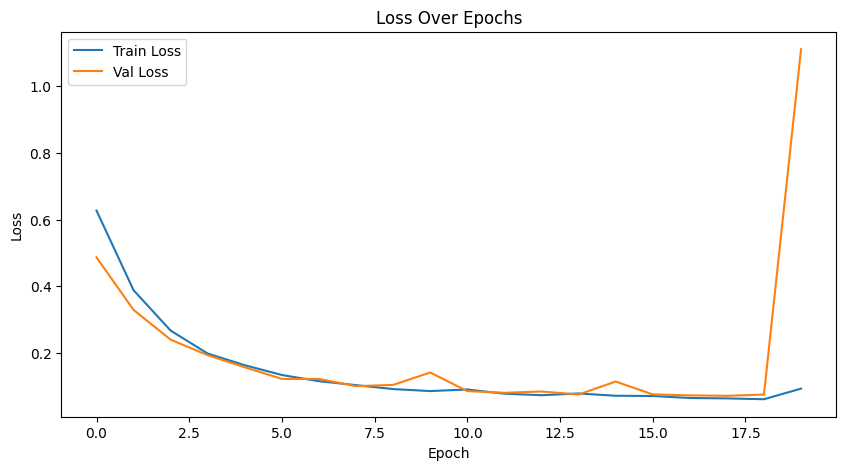

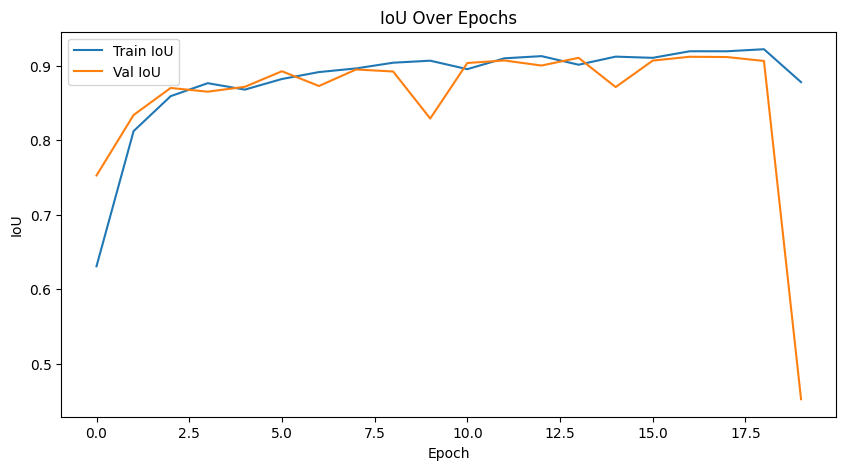

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import os

for i in range(100):
    if os.path.isdir(f'logs/segmentation_model/version_{i}'):
        try:
            metrics = pd.read_csv(f'logs/segmentation_model/version_{i}/metrics.csv')
        except Exception:
            pass
    else:
        break

metrics = metrics.drop(columns=['step'])
metrics = metrics.dropna(subset=['epoch'])

metrics['epoch'] = metrics['epoch'].astype(int)
metrics = metrics.groupby(['epoch'], as_index=False).sum()

plt.figure(figsize=(10, 5))
plt.plot(metrics['epoch'], metrics['train_avg_loss'], label='Train Loss')
plt.plot(metrics['epoch'], metrics['val_avg_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(metrics['epoch'], metrics['train_iou'], label='Train IoU')
plt.plot(metrics['epoch'], metrics['val_iou'], label='Val IoU')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.title('IoU Over Epochs')
plt.legend()
plt.show()


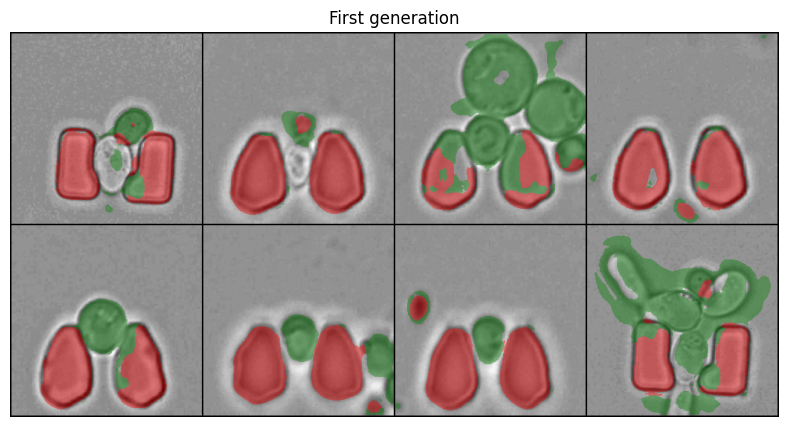

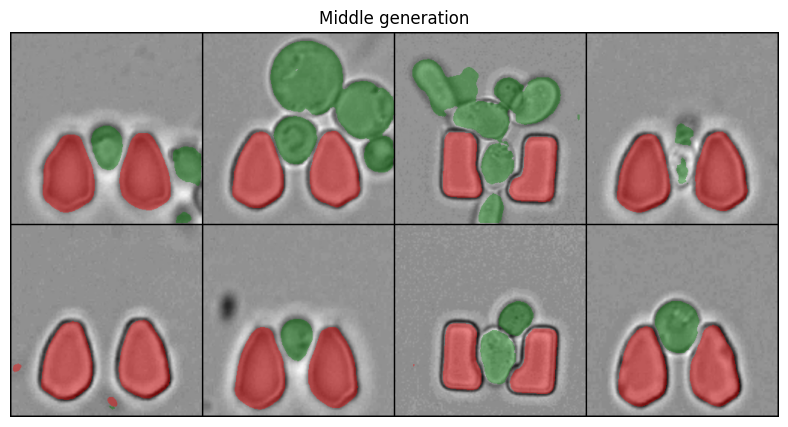

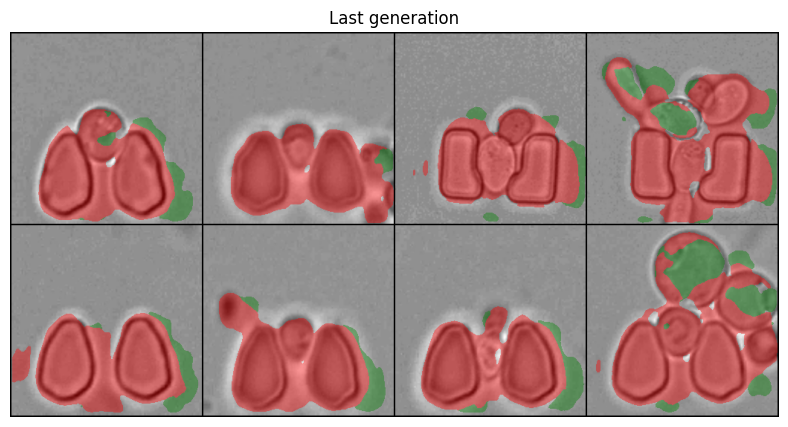

In [83]:
from PIL import Image

# Function to display images
def display_prediction(epoch, title):
    image_path = Path('predictions') / f'epoch_{epoch}_predictions.png'
    image = Image.open(image_path)
    plt.figure(figsize=(10, 5))
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

display_prediction(epoch=0, title='First generation')
display_prediction(epoch=trainer.max_epochs // 2, title='Middle generation')
display_prediction(epoch=trainer.max_epochs - 1, title='Last generation')


### Задание 3 (3 балла). Выбор другой функции ошибки

Полезная ссылка:
https://www.jeremyjordan.me/semantic-segmentation/#loss

Повторите эксперимент из задания 2, но попробуйте модифицировать функцию ошибки:
- (2 балла) учитывайте пиксели на границе объектов с большим весом, как предлагается в статье [U-Net](https://arxiv.org/abs/1505.04597)
- (1 балл) используйте soft Dice loss

Опишите свои наблюдения, что изменилось? Обратите внимание на скорость обучения, визуальные артефакты предсказаний, динамику метрик.


### Задание 4 (3 балла). Модификация архитектуры

Ваша задача - извлечь максимальную точность из модели, в которой будет не более 50k параметров. Для этого внесите правки в архитектуру модели.

В частности, попробуйте заменить в блоке `Down` комбинацию conv+maxpool на dilated conv (`nn.Conv2d(..., dilation=2)`). В остальном - полная свобода творчества, можете перерабатывать архитектуру как угодно.

Как обычно, запустите эксперимент (или несколько) с выводом всех графиков и картинок.